# 01 · §7.1 Quantitative Results (H1)

Per-(dataset, teacher) tables of test **mAP@R / R-Precision / Recall@K** (mean ± sem over ≥3 seeds) for the 5 students, plus the grouped mAP@R bar chart. Verdict by the §8 rule: *matches* if the interval overlaps the best baseline; *beats* only if mean > best baseline + 1 sem **and** the sign is consistent across teachers — reported per cell, never averaged over a sign flip.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # RKD/ on path
sys.path.insert(0, os.getcwd())
import analysis_utils as au
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df = pd.read_csv('results.csv')
cells = df[df.phase=='phase5'][['dataset','teacher']].dropna().drop_duplicates()
cells = list(cells.itertuples(index=False, name=None)); cells

[('cars196', 'resnet18'),
 ('cars196', 'convnext_tiny'),
 ('cub200', 'resnet18'),
 ('cub200', 'convnext_tiny')]

### Headline tables (one per cell)

In [3]:
for d,t in cells:
    print(f'=== {d} · {t} ===')
    tab = au.headline_table(df, d, t, 'test_mAP@R')
    display(tab)
    print('H1:', au.h1_verdict(tab), '\n')

=== cars196 · resnet18 ===


,student,median,mean,sem,n
4,triplet-only,0.0307,0.0324,0.0020,3
3,+RKD-D,0.0179,0.0181,0.0008,3
1,+RKD-A,0.0193,0.0194,0.0010,3
2,+RKD-D+RKD-A,0.0176,0.0176,0.0011,3
0,+Graph-RKD,0.0346,0.0345,0.0015,6


H1: Graph-RKD VENCE triplet-only (mediana 0.0346 > 0.0307) 

=== cars196 · convnext_tiny ===


,student,median,mean,sem,n
4,triplet-only,0.0307,0.0324,0.0020,3
3,+RKD-D,0.0205,0.0205,NaN,1
1,+RKD-A,0.0213,0.0213,NaN,1
2,+RKD-D+RKD-A,0.0185,0.0185,NaN,1
0,+Graph-RKD,0.0362,0.0357,0.0010,3


H1: Graph-RKD VENCE triplet-only (mediana 0.0362 > 0.0307) 

=== cub200 · resnet18 ===


,student,median,mean,sem,n
4,triplet-only,0.0284,0.0284,NaN,1
3,+RKD-D,0.0336,0.0336,NaN,1
1,+RKD-A,0.0361,0.0361,NaN,1
2,+RKD-D+RKD-A,0.0340,0.0340,NaN,1
0,+Graph-RKD,0.0294,0.0302,0.0012,3


H1: Graph-RKD PERDE p/ +RKD-A (mediana 0.0294 < 0.0361) 

=== cub200 · convnext_tiny ===


,student,median,mean,sem,n
4,triplet-only,0.0284,0.0284,NaN,1
3,+RKD-D,0.0297,0.0297,NaN,1
1,+RKD-A,0.0312,0.0312,NaN,1
2,+RKD-D+RKD-A,0.0310,0.0310,NaN,1
0,+Graph-RKD,0.0300,0.0303,0.0004,3


H1: Graph-RKD PERDE p/ +RKD-A (mediana 0.0300 < 0.0312) 



### R-Precision and Recall@1 (secondary)

In [4]:
for m in ['test_R_precision','test_recall@1']:
    print('---', m, '---')
    for d,t in cells: display(au.headline_table(df, d, t, m))

--- test_R_precision ---


,student,median,mean,sem,n
4,triplet-only,0.0875,0.0914,0.0043,3
3,+RKD-D,0.0648,0.0631,0.0019,3
1,+RKD-A,0.0679,0.0653,0.0031,3
2,+RKD-D+RKD-A,0.0646,0.0619,0.0030,3
0,+Graph-RKD,0.0944,0.0943,0.0034,6


,student,median,mean,sem,n
4,triplet-only,0.0875,0.0914,0.0043,3
3,+RKD-D,0.0694,0.0694,NaN,1
1,+RKD-A,0.0696,0.0696,NaN,1
2,+RKD-D+RKD-A,0.0649,0.0649,NaN,1
0,+Graph-RKD,0.0998,0.0985,0.0017,3


,student,median,mean,sem,n
4,triplet-only,0.0814,0.0814,NaN,1
3,+RKD-D,0.0887,0.0887,NaN,1
1,+RKD-A,0.0956,0.0956,NaN,1
2,+RKD-D+RKD-A,0.0918,0.0918,NaN,1
0,+Graph-RKD,0.0827,0.0827,0.0012,3


,student,median,mean,sem,n
4,triplet-only,0.0814,0.0814,NaN,1
3,+RKD-D,0.0816,0.0816,NaN,1
1,+RKD-A,0.0855,0.0855,NaN,1
2,+RKD-D+RKD-A,0.0857,0.0857,NaN,1
0,+Graph-RKD,0.0804,0.0804,0.0008,3


--- test_recall@1 ---


,student,median,mean,sem,n
4,triplet-only,0.2096,0.2264,0.0180,3
3,+RKD-D,0.1377,0.1372,0.0058,3
1,+RKD-A,0.1405,0.1364,0.0075,3
2,+RKD-D+RKD-A,0.1359,0.1329,0.0067,3
0,+Graph-RKD,0.2405,0.2378,0.0103,6


,student,median,mean,sem,n
4,triplet-only,0.2096,0.2264,0.0180,3
3,+RKD-D,0.1477,0.1477,NaN,1
1,+RKD-A,0.1428,0.1428,NaN,1
2,+RKD-D+RKD-A,0.1280,0.1280,NaN,1
0,+Graph-RKD,0.2591,0.2555,0.0050,3


,student,median,mean,sem,n
4,triplet-only,0.1338,0.1338,NaN,1
3,+RKD-D,0.1590,0.1590,NaN,1
1,+RKD-A,0.1740,0.1740,NaN,1
2,+RKD-D+RKD-A,0.1617,0.1617,NaN,1
0,+Graph-RKD,0.1426,0.1443,0.0035,3


,student,median,mean,sem,n
4,triplet-only,0.1338,0.1338,NaN,1
3,+RKD-D,0.1465,0.1465,NaN,1
1,+RKD-A,0.1477,0.1477,NaN,1
2,+RKD-D+RKD-A,0.1546,0.1546,NaN,1
0,+Graph-RKD,0.1419,0.1436,0.0035,3


### Grouped mAP@R bar chart (Figure for §7.1)

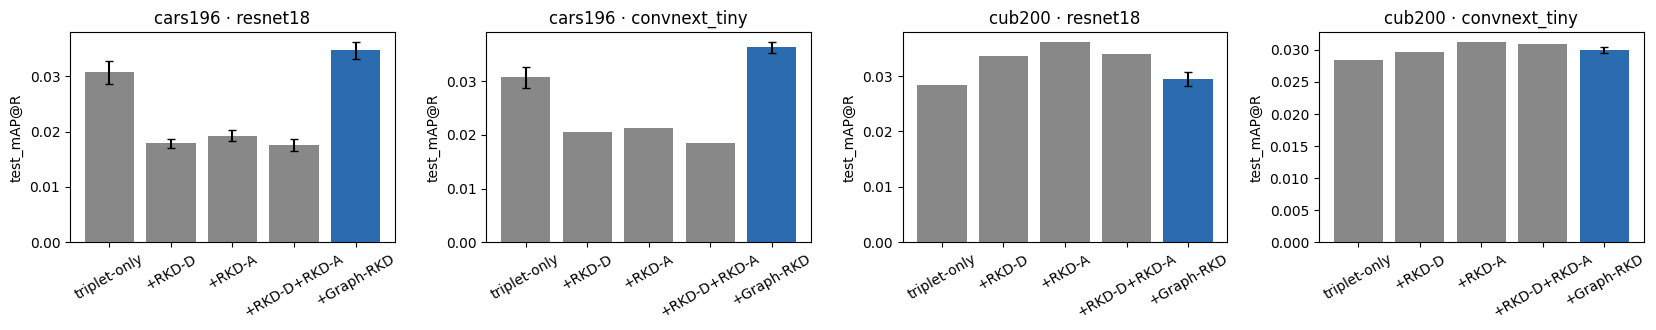

In [5]:
au.fig_h1_bar(df);